In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [2]:
TRAIN_DIR = r"C:\Users\Noha\OneDrive\Desktop\AI101\Deep Learning\mini projet\data\Training"
TEST_DIR = r"C:\Users\Noha\OneDrive\Desktop\AI101\Deep Learning\mini projet\data\Testing"

In [3]:
import os

print(os.listdir(TRAIN_DIR))

['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
import cv2
import os
import numpy as np

IMG_SIZE = 224

images = []
labels = []

classes = ['glioma', 'meningioma', 'pituitary', 'notumor']

for label in classes:
    
    folder = os.path.join(TRAIN_DIR, label)
    
    for image_name in os.listdir(folder):
        
        image_path = os.path.join(folder, image_name)
        
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        
        images.append(image)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(5600, 224, 224, 3)
(5600,)


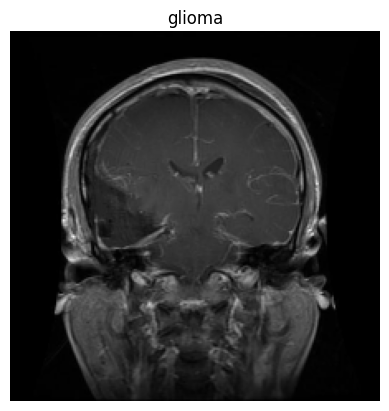

In [5]:
import matplotlib.pyplot as plt

plt.imshow(X[0])
plt.title(y[0])
plt.axis("off")
plt.show()

## Partie 2 : EDA

In [6]:

classes = os.listdir(TRAIN_DIR)

data = []

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(folder))
    
    data.append([cls, count])

df_classes = pd.DataFrame(data, columns=["Class", "Count"])

df_classes

,Class,Count
0,glioma,1400
1,meningioma,1400
2,notumor,1400
3,pituitary,1400


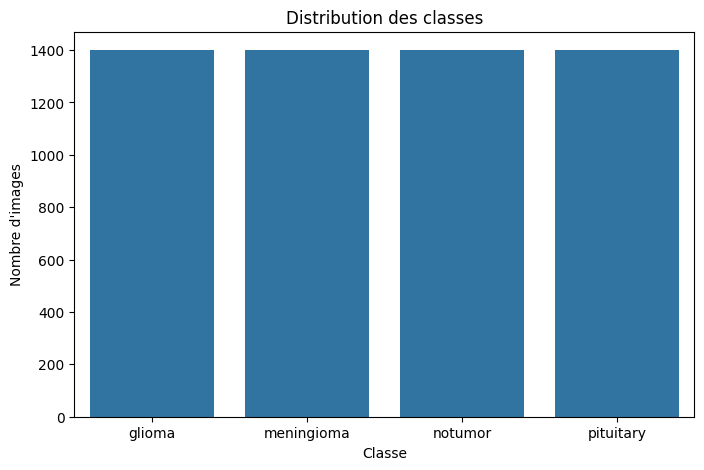

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Class",
    y="Count",
    data=df_classes
)

plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")

plt.show()

Cette figure présente la répartition des images selon les différentes classes. Une distribution relativement équilibrée permet d'éviter les biais lors de l'entraînement du modèle

In [8]:
df_classes["Percentage"] = (
    df_classes["Count"] /
    df_classes["Count"].sum()
) * 100

df_classes

,Class,Count,Percentage
0,glioma,1400,25.0
1,meningioma,1400,25.0
2,notumor,1400,25.0
3,pituitary,1400,25.0


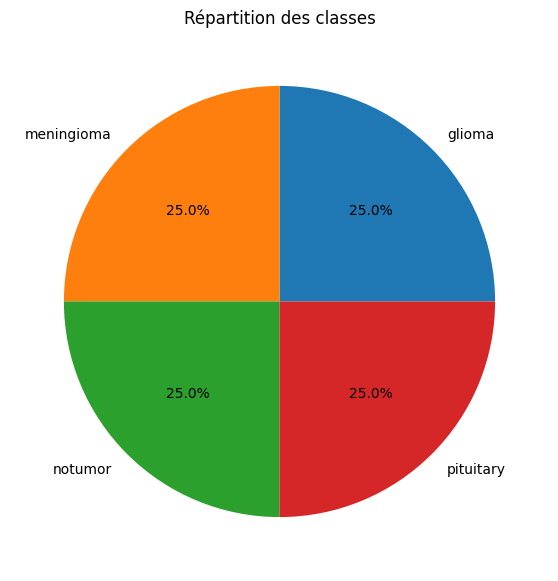

In [9]:
plt.figure(figsize=(7,7))

plt.pie(
    df_classes["Count"],
    labels=df_classes["Class"],
    autopct="%1.1f%%"
)

plt.title("Répartition des classes")
plt.show()

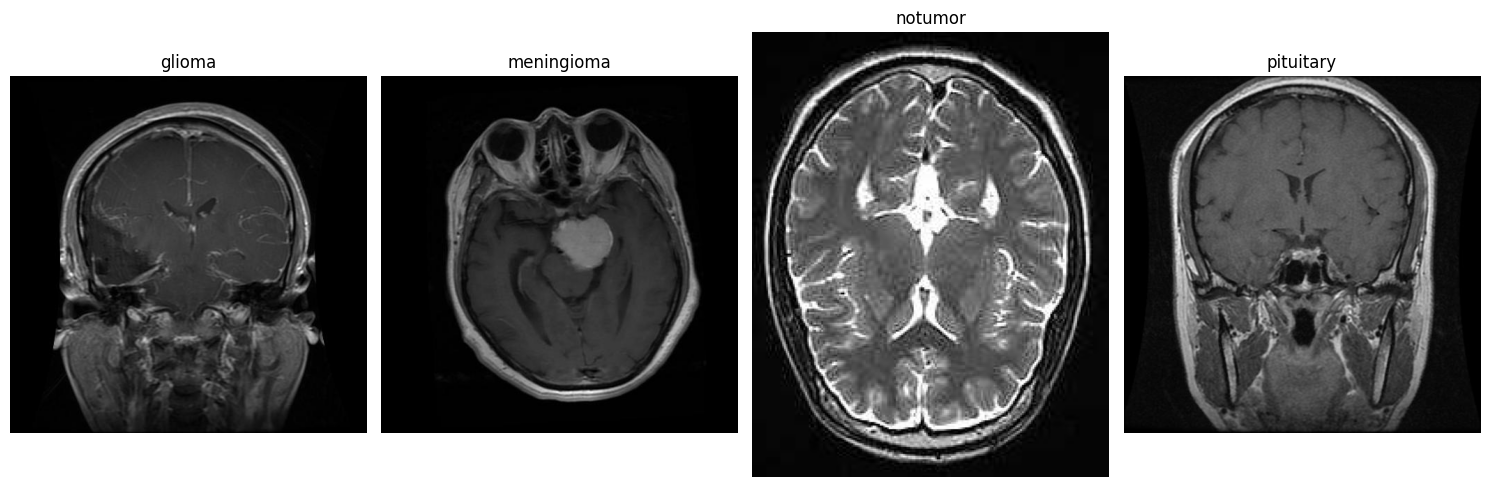

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15,5))

for i, cls in enumerate(classes):

    folder = os.path.join(TRAIN_DIR, cls)

    img_name = os.listdir(folder)[0]

    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Les images IRM présentent des caractéristiques visuelles différentes selon le type de tumeur, ce qui justifie l'utilisation d'un modèle CNN capable d'extraire automatiquement les caractéristiques pertinentes.

In [11]:
widths = []
heights = []

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(folder)[:100]:

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        h, w, _ = img.shape

        heights.append(h)
        widths.append(w)

print("Hauteur moyenne :", np.mean(heights))
print("Largeur moyenne :", np.mean(widths))

Hauteur moyenne : 461.5325
Largeur moyenne : 459.905


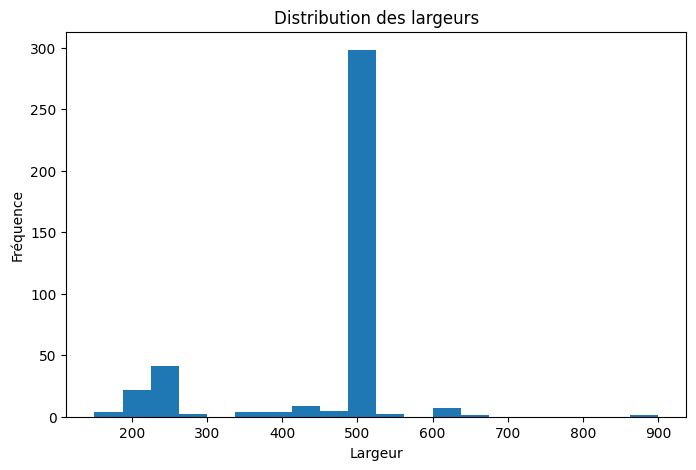

In [12]:
plt.figure(figsize=(8,5))

plt.hist(widths, bins=20)

plt.title("Distribution des largeurs")
plt.xlabel("Largeur")
plt.ylabel("Fréquence")

plt.show()

### Vérification des valeurs manquantes ou corrompues

In [13]:
corrupted = 0

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        if img is None:
            corrupted += 1

print("Images corrompues :", corrupted)

Images corrompues : 0


### Conclusion de l'analyse exploratoire

- Le dataset contient quatre classes :
  - Glioma
  - Meningioma
  - Pituitary
  - No Tumor

- La distribution des classes est globalement équilibrée.

- Les images présentent différentes dimensions, ce qui nécessite une étape de redimensionnement avant l'entraînement.

- Aucune image corrompue n'a été détectée.

- Le dataset est adapté à une tâche de classification multi-classes basée sur les réseaux de neurones convolutifs.

## Partie 3 : Preprocessing

### Normalisation

In [14]:
X_train = []
y_train = []

X_test = []
y_test = []

for label in classes:

    folder = os.path.join(TRAIN_DIR, label)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X_train.append(img)

        y_train.append(label)

for label in classes:

    folder = os.path.join(TEST_DIR, label)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X_test.append(img)

        y_test.append(label)        

In [15]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print(X_train.shape)
print(X_test.shape)

(5600, 224, 224, 3)
(1600, 224, 224, 3)


In [16]:
X_train = X_train.astype('float32') / 255.0

X_test = X_test.astype('float32') / 255.0

In [17]:
print(X_train.min())
print(X_train.max())

0.0
1.0


### Encodage des classes

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)

y_test_encoded = encoder.transform(y_test)

In [19]:
print(encoder.classes_)

['glioma' 'meningioma' 'notumor' 'pituitary']


In [20]:
# One-Hot Encoding
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train_encoded)

y_test_cat = to_categorical(y_test_encoded)

In [21]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

In [22]:
print(X_train_final.shape)
print(X_val.shape)
print(y_train_final.shape)
print(y_val.shape)

(4480, 224, 224, 3)
(1120, 224, 224, 3)
(4480, 4)
(1120, 4)


### Data Augmentation

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

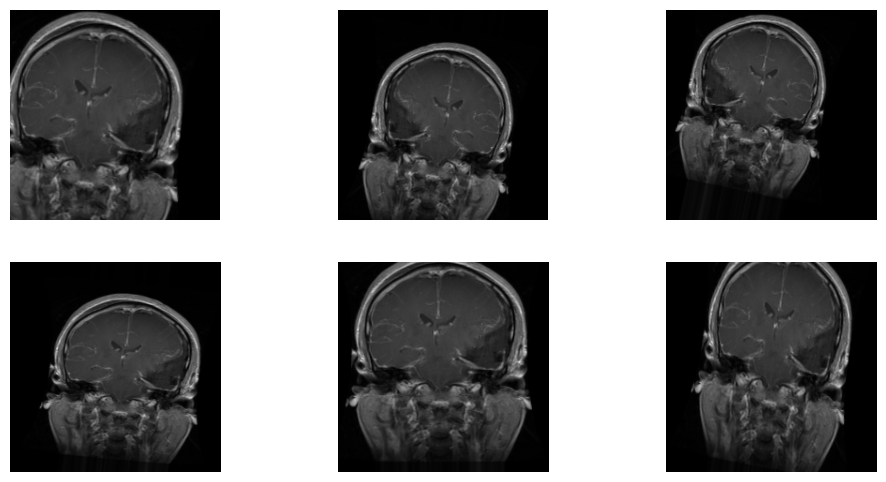

In [24]:
sample = X_train[0].reshape((1,) + X_train[0].shape)

plt.figure(figsize=(12,6))

i = 0

for batch in datagen.flow(sample, batch_size=1):

    plt.subplot(2,3,i+1)

    plt.imshow(batch[0])

    plt.axis('off')

    i += 1

    if i == 6:
        break

plt.show()

In [25]:
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

In [26]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [27]:
base_model.trainable = False

In [28]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    4,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [32]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [33]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [34]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [35]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

In [36]:
print(X_train_final.shape)
print(X_val.shape)

(4480, 224, 224, 3)
(1120, 224, 224, 3)


In [37]:
history = model.fit(

    datagen.flow(
        X_train_final,
        y_train_final,
        batch_size=32
    ),

    validation_data=(
        X_val,
        y_val
    ),

    epochs=20,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6750 - loss: 0.8296
Epoch 1: val_accuracy improved from None to 0.81161, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.7746 - loss: 0.5912 - val_accuracy: 0.8116 - val_loss: 0.5042 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8469 - loss: 0.4000
Epoch 2: val_accuracy did not improve from 0.81161
140/140 ━━━━━━━━━━━━━━━━━━━━ 498s 4s/step - accuracy: 0.8460 - loss: 0.3931 - val_accuracy: 0.8098 - val_loss: 0.4813 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8578 - loss: 0.3559
Epoch 3: val_accuracy did not improve from 0.81161
140/140 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.8616 - loss: 0.3476 - val_accuracy: 0.7964 - val_loss: 0.4921 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8910 - loss: 0

In [38]:
print(X_train.dtype)
print(X_train.min(), X_train.max())

float32
0.0 1.0


In [39]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


In [40]:
train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]

print(f"\nTrain Accuracy     : {train_acc * 100:.2f}%")
print(f" Validation Accuracy: {val_acc   * 100:.2f}%")


Train Accuracy     : 93.24%
 Validation Accuracy: 90.09%


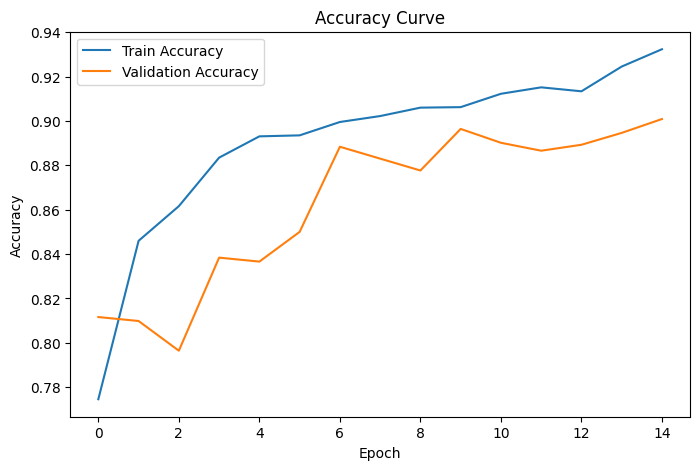

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

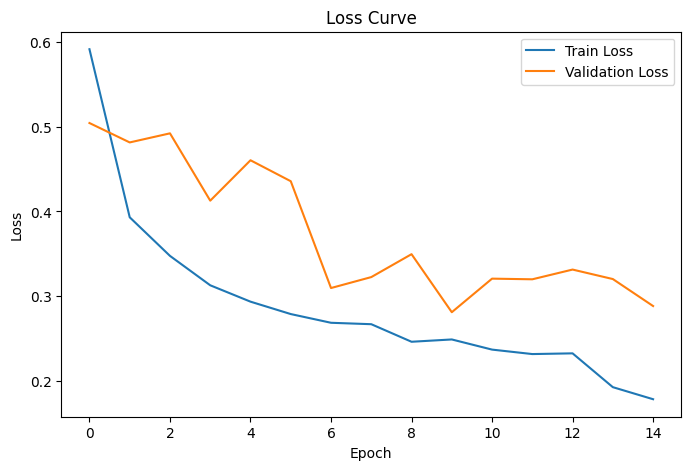

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [43]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 887ms/step - accuracy: 0.8413 - loss: 0.5614
Test Accuracy: 84.13%


In [44]:
y_pred = model.predict(X_test)

y_pred_classes = y_pred.argmax(axis=1)

y_true = y_test_cat.argmax(axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 890ms/step


In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      glioma       0.95      0.63      0.76       400
  meningioma       0.73      0.76      0.74       400
     notumor       0.88      0.98      0.93       400
   pituitary       0.84      0.99      0.91       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.84      1600
weighted avg       0.85      0.84      0.84      1600



In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

print(cm)

[[253 106  23  18]
 [ 10 302  31  57]
 [  1   3 394   2]
 [  1   2   0 397]]


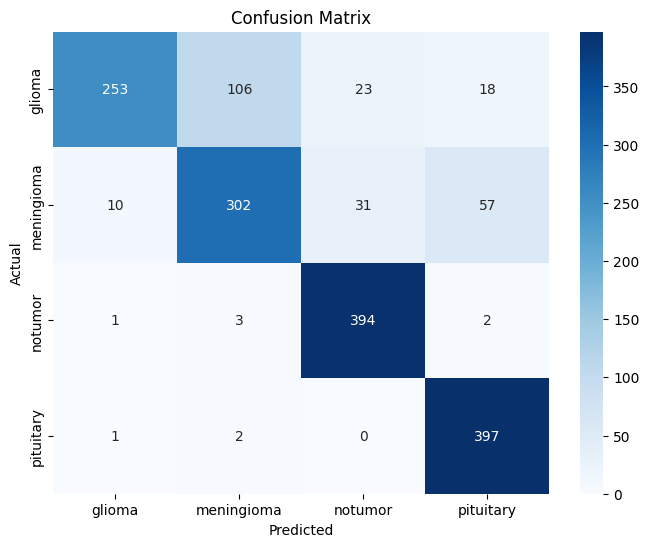

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [48]:
model.save("brain_tumor_model.keras")

In [49]:
import joblib

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

['label_encoder.pkl']

In [50]:
import cv2
import numpy as np

def predict_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224,224))

    img = img.astype("float32") / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    class_name = encoder.inverse_transform(
        [predicted_class]
    )[0]

    return class_name, confidence

In [51]:
result, conf = predict_image(
    r"C:\Users\Noha\OneDrive\Desktop\AI101\Deep Learning\mini projet\data\Testing\glioma\Te-gl_37.jpg"
)

print(result)
print(conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
glioma
0.9884012


In [52]:
result, conf = predict_image(
    r"C:\Users\Noha\OneDrive\Desktop\AI101\Deep Learning\mini projet\data\Testing\meningioma\Te-aug-me_10.jpg"
)

print(result)
print(conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
pituitary
0.8369082


In [53]:
from collections import Counter

print(Counter(y_train))

Counter({np.str_('glioma'): 1400, np.str_('meningioma'): 1400, np.str_('notumor'): 1400, np.str_('pituitary'): 1400})
